# Modelado: predicción de reingreso hospitalario

Aquí se entrenan y comparan cuatro modelos a ver cuál se ajusta mejor a este problema. La evaluación a fondo del ganador se deja para `04_evaluation.ipynb`; en este notebook lo importante es la comparación inicial entre algoritmos.

Los modelos probados son:

- **Regresión Logística** como baseline lineal. Sirve para tener una referencia y saber cuánto se gana al pasar a modelos no lineales.
- **Random Forest**, un bagging de árboles, para ver si captura mejor las interacciones.
- **XGBoost** y **LightGBM**, dos implementaciones de gradient boosting. Suelen ser los más competitivos en problemas tabulares como este.

**Métricas en las que me fijo:** sobre todo ROC-AUC (capacidad de ordenar el riesgo) y Recall (cuántos reingresos reales se detectan). En sanidad detectar un reingreso de más cuesta una llamada y una revisión; no detectarlo puede traducirse en una readmisión que se hubiera podido evitar.

## 1. Imports y configuración

In [1]:
import sys
import os
sys.path.append(os.path.abspath(".."))

import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import roc_curve, roc_auc_score

from src.models.train import (
    load_data, split_data, get_models,
    run_all_models, cross_validate_model, tune_model, get_metrics
)
from src.evaluation.evaluate import (
    plot_confusion_matrix, get_classification_report
)

## 2. Carga del dataset

In [2]:
X, y, groups = load_data()

print(f"Dataset: {X.shape[0]:,} registros — {X.shape[1]} variables predictoras")
print(f"\nDistribución de la variable objetivo:")
print(y.value_counts())
print(f"\nProporción positivos (readmisión): {y.mean():.1%}")

Dataset cargado: 315,982 registros, 54 variables. Tasa positivos: 0.342. Split: por paciente (GroupShuffleSplit)
Dataset: 315,982 registros — 54 variables predictoras

Distribución de la variable objetivo:
readmission_30_days
0    208032
1    107950
Name: count, dtype: int64

Proporción positivos (readmisión): 34.2%


### Nota sobre el desbalanceo de clases

La target queda en 65,8 % de negativos y 34,2 % de positivos. No es un desbalanceo brutal, pero con el umbral por defecto de 0,5 los modelos se vuelven perezosos: como predecir todo a "no reingresa" ya les da ~66 % de accuracy, el recall sobre la clase positiva se hunde.

Para evitarlo, ajusto los pesos de clase para que el coste de fallar en la clase minoritaria sea mayor: `class_weight='balanced'` en Regresión Logística y Random Forest, y `scale_pos_weight = N_neg / N_pos` (≈ 1,93) en XGBoost y LightGBM. La idea es la misma (penalizar más los falsos negativos, que en este contexto clínico son lo que más duele).

## 3. División en entrenamiento, validación y test

In [3]:
X_train, X_val, X_test, y_train, y_val, y_test = split_data(X, y, groups)

print(f"Train: {X_train.shape[0]:,} registros ({y_train.mean():.1%} positivos)")
print(f"Val:   {X_val.shape[0]:,} registros ({y_val.mean():.1%} positivos)")
print(f"Test:  {X_test.shape[0]:,} registros ({y_test.mean():.1%} positivos)")

Train: 189,245 registros (34.2% positivos)
Val:   62,611 registros (33.8% positivos)
Test:  64,126 registros (34.6% positivos)


## 4. Entrenamiento y comparación de modelos

Los cuatro modelos se entrenan sobre `X_train` con la misma configuración base y se evalúan en `X_val`. El test set ni se toca aquí (se reserva para el final, después de elegir y tunear el ganador, para que la métrica que se reporte no esté contaminada por la propia selección).

Para ordenarlos uso ROC-AUC como criterio principal y Average Precision como desempate si hay AUC muy parecidos.

In [4]:
results_df, trained_models = run_all_models(X_train, X_val, y_train, y_val)
results_df

Training models...
  Training Logistic Regression...
  Training Random Forest...
  Training XGBoost...
  Training LightGBM...


,Accuracy,Precision,Recall,F1-score,ROC-AUC,Avg Precision,Train time (s)
Model,,,,,,,
LightGBM,0.6135,0.4451,0.5866,0.5062,0.6509,0.4816,0.9
XGBoost,0.6142,0.4455,0.5819,0.5046,0.6500,0.4820,2.4
Logistic Regression,0.6133,0.4412,0.5443,0.4873,0.6327,0.4537,1.1
Random Forest,0.6493,0.4578,0.2093,0.2873,0.6094,0.4267,18.0


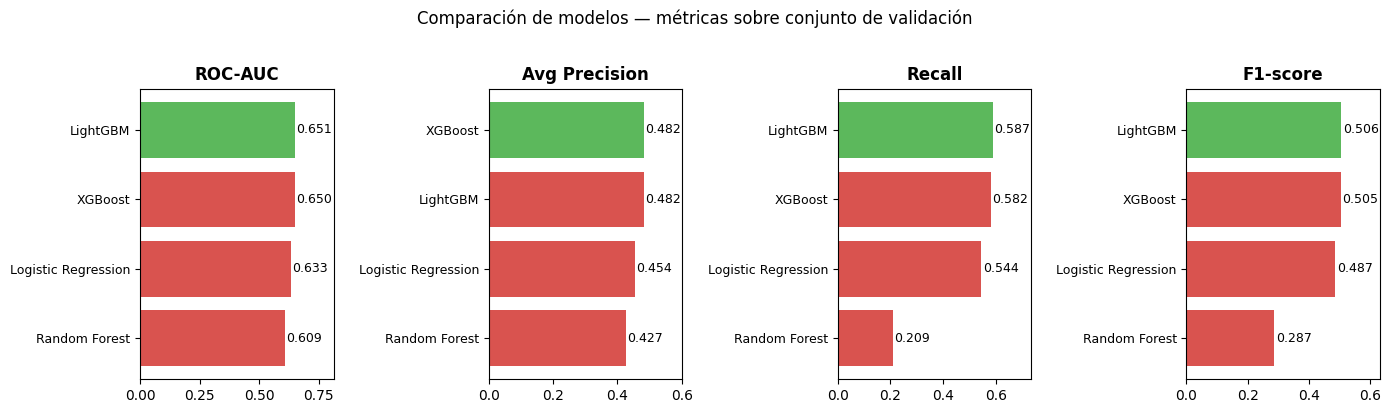

In [5]:
# Gráfico comparativo de modelos en las métricas clave
metrics_to_plot = ["ROC-AUC", "Avg Precision", "Recall", "F1-score"]
fig, axes = plt.subplots(1, 4, figsize=(14, 4))

for ax, metric in zip(axes, metrics_to_plot):
    values = results_df[metric].sort_values()
    colors = ["#d9534f" if m != results_df[metric].idxmax() else "#5cb85c" for m in values.index]
    bars = ax.barh(values.index, values.values, color=colors)
    ax.set_xlim(0, max(values.values) * 1.25)
    ax.set_title(metric, fontweight="bold")
    ax.set_xlabel("")
    for bar, val in zip(bars, values.values):
        ax.text(val + 0.005, bar.get_y() + bar.get_height() / 2,
                f"{val:.3f}", va="center", fontsize=9)
    ax.tick_params(axis="y", labelsize=9)

plt.suptitle("Comparación de modelos — métricas sobre conjunto de validación", fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig("../results/model_comparison_bar.png", dpi=150, bbox_inches="tight")
plt.show()

### Justificación de la selección del modelo

Para decidir con cuál seguir miré tres cosas: cómo discrimina (ROC-AUC), cuánto recall consigue con el umbral por defecto, y si era razonable de interpretar después con SHAP.

**Regresión Logística** se queda como baseline. AUC 0,633 (el más bajo del grupo). No me sorprende, en este dataset hay claras interacciones entre variables (edad × diagnóstico, estancia × ingresos previos…) que un modelo lineal no puede capturar bien.

**Random Forest**, en cambio, decepcionó. AUC parece razonable (0,609) pero el Recall se queda en 0,21: detecta solo 1 de cada 5 reingresos. Para una herramienta de screening clínico eso es prácticamente inservible (el sentido del modelo es justamente el contrario: no dejar escapar los casos en riesgo).

**XGBoost y LightGBM** llegan casi empatados (AUC 0,6500 vs 0,6509). La diferencia es ridícula y prácticamente cualquier semilla aleatoria distinta podría darle la vuelta. Me quedo con **LightGBM** porque es el que sale ligeramente mejor y porque entrena bastante más rápido, lo que viene bien para luego hacer el tuning con muchas iteraciones. Después de optimizar, llega a un AUC de 0,6567 sobre test.

El análisis completo del modelo elegido está en `04_evaluation.ipynb`.

## 4.1 Curvas ROC: comparación de los cuatro modelos base


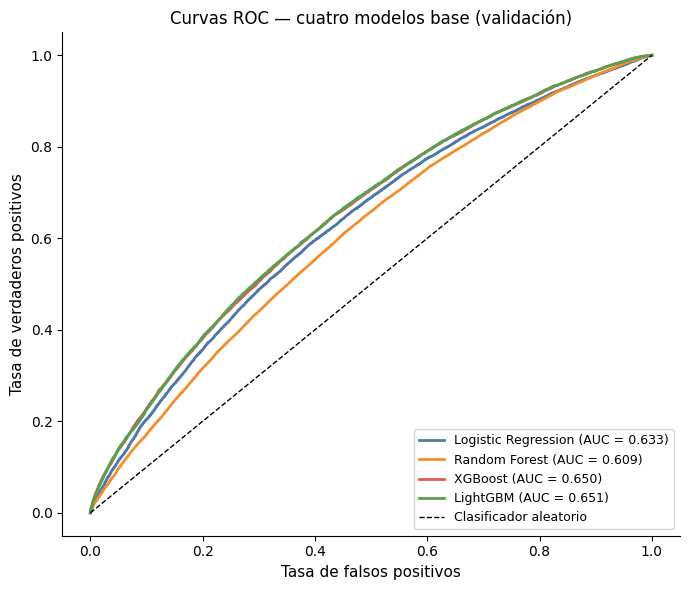

Guardado: results/roc_4models.png


In [6]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Solo los 4 modelos base, evaluados sobre validación
base_models = {k: v for k, v in trained_models.items() if "tuned" not in k.lower()}

fig, ax = plt.subplots(figsize=(7, 6))
colors = ["#4e79a7", "#f28e2b", "#e15759", "#59a14f"]

for (name, model), color in zip(base_models.items(), colors):
    y_prob = model.predict_proba(X_val)[:, 1]
    fpr, tpr, _ = roc_curve(y_val, y_prob)
    auc = roc_auc_score(y_val, y_prob)
    ax.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})", color=color, lw=2)

ax.plot([0, 1], [0, 1], "k--", lw=1, label="Clasificador aleatorio")
ax.set_xlabel("Tasa de falsos positivos", fontsize=11)
ax.set_ylabel("Tasa de verdaderos positivos", fontsize=11)
ax.set_title("Curvas ROC — cuatro modelos base (validación)", fontsize=12)
ax.legend(loc="lower right", fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("../results/roc_4models.png", dpi=180, bbox_inches="tight")
plt.show()
print("Guardado: results/roc_4models.png")

## 5. Validación cruzada del mejor modelo

Para asegurarme de que el rendimiento no es producto del azar de un único split, hago una CV de 5 folds *solo sobre train*. Val y test siguen sin tocarse.

Es de esperar que el AUC medio del CV salga algo más bajo que el que dio sobre validación: cada fold entrena con menos datos que el modelo completo, así que es lo normal.

In [7]:
best_model_name = results_df.index[0]
best_model = trained_models[best_model_name]

print(f"Mejor modelo: {best_model_name}")
print(f"ROC-AUC (val): {results_df.loc[best_model_name, 'ROC-AUC']}")

# CV solo sobre train — ni val ni test participan aquí
groups_train = groups.loc[X_train.index]
cv_results = cross_validate_model(best_model, X_train, y_train, cv=5, groups=groups_train)
print(f"ROC-AUC (CV 5-fold sobre train): {cv_results['cv_roc_auc_mean']} ± {cv_results['cv_roc_auc_std']}")

Mejor modelo: LightGBM
ROC-AUC (val): 0.6509
ROC-AUC (CV 5-fold sobre train): 0.6529 ± 0.0029


## 6. Optimización de hiperparámetros

Hasta aquí LightGBM iba con sus hiperparámetros por defecto. Toca probar si afinándolos se gana algo. Lo hago con `RandomizedSearchCV`:

- 20 combinaciones aleatorias del espacio de búsqueda (mejor que GridSearch para este número de parámetros: exploración más amplia con menos cómputo)
- CV interna de 3 folds, otra vez **solo sobre `X_train`**
- scoring por ROC-AUC

Con los mejores parámetros se reentrena el modelo sobre `X_train` entero y, ya por fin, se evalúa en `X_test`. Si la mejora respecto al modelo base es decente, ese es el modelo que se guarda como definitivo.

In [8]:
groups_train = groups.loc[X_train.index]
best_model_tuned, best_params, tune_cv = tune_model(
    best_model_name, X_train, y_train, n_iter=20, cv=3, groups=groups_train
)

# comparamos baseline y optimizado sobre test
# (results_df tenía métricas de validación, aquí los dos se evalúan en test)
y_pred_base  = trained_models[best_model_name].predict(X_test)
y_prob_base  = trained_models[best_model_name].predict_proba(X_test)[:, 1]
metrics_base_test = get_metrics(y_test, y_pred_base, y_prob_base)

y_pred_tuned = best_model_tuned.predict(X_test)
y_prob_tuned = best_model_tuned.predict_proba(X_test)[:, 1]
metrics_tuned = get_metrics(y_test, y_pred_tuned, y_prob_tuned)

print("\n--- Comparación baseline vs optimizado (ambos sobre test set) ---")
print(f"{'Métrica':<18} {'Baseline':>10} {'Optimizado':>10} {'Mejora':>10}")
print("-" * 50)
for metric in ["ROC-AUC", "Avg Precision", "Recall", "F1-score"]:
    baseline = round(metrics_base_test[metric], 4)
    tuned    = round(metrics_tuned[metric], 4)
    diff     = round(tuned - baseline, 4)
    sign     = "+" if diff >= 0 else ""
    print(f"{metric:<18} {baseline:>10.4f} {tuned:>10.4f} {sign+str(diff):>10}")

print(f"\nROC-AUC (CV interna optimización, 3 folds): {tune_cv['cv_roc_auc_mean']} ± {tune_cv['cv_roc_auc_std']}")

# el optimizado es el modelo principal de aquí en adelante
best_model = best_model_tuned
best_model_name = f"{best_model_name} (optimizado)"
trained_models[best_model_name] = best_model

Optimizando hiperparámetros de LightGBM (20 iteraciones, CV=3)...
Fitting 3 folds for each of 20 candidates, totalling 60 fits

Mejores hiperparámetros: {'subsample': 0.8, 'num_leaves': 127, 'n_estimators': 600, 'min_child_samples': 20, 'max_depth': -1, 'learning_rate': 0.01, 'colsample_bytree': 0.8, 'bagging_freq': 5}
ROC-AUC medio (CV interna): 0.6549

--- Comparación baseline vs optimizado (ambos sobre test set) ---
Métrica              Baseline Optimizado     Mejora
--------------------------------------------------
ROC-AUC                0.6541     0.6567    +0.0026
Avg Precision          0.5039     0.5085    +0.0046
Recall                 0.5940     0.5960     +0.002
F1-score               0.5145     0.5163    +0.0018

ROC-AUC (CV interna optimización, 3 folds): 0.6549 ± 0.0038


## 7. Curvas ROC: comparación de modelos

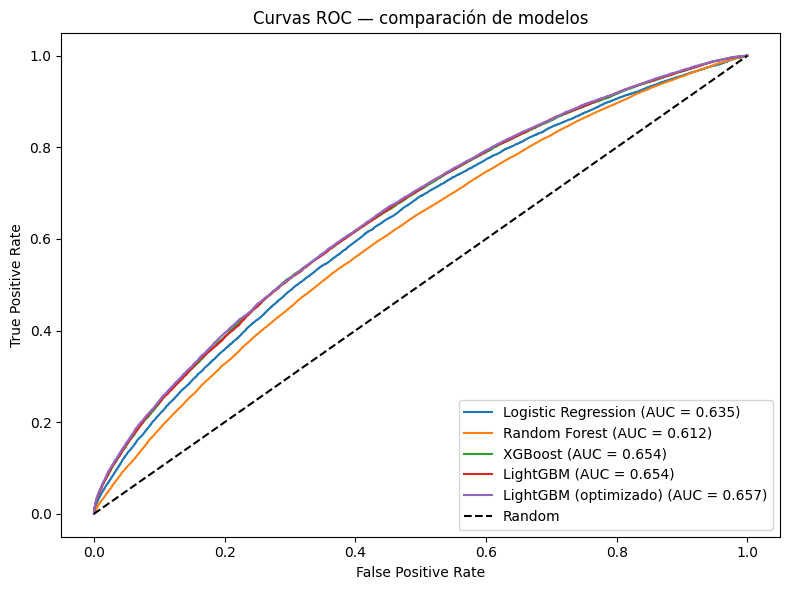

In [9]:
plt.figure(figsize=(8, 6))

for name, model in trained_models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")

plt.plot([0, 1], [0, 1], "k--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curvas ROC — comparación de modelos")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("../results/roc_curves_comparison.png", dpi=150)
plt.show()

## 8. Matriz de confusión del mejor modelo

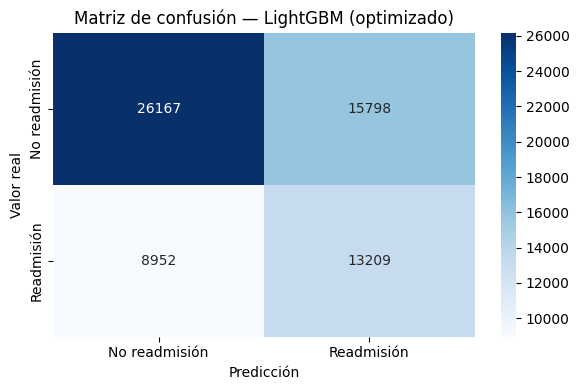


Classification Report:
               precision  recall  f1-score    support
No readmisión      0.745   0.624     0.679  41965.000
Readmisión         0.455   0.596     0.516  22161.000
accuracy           0.614   0.614     0.614      0.614
macro avg          0.600   0.610     0.598  64126.000
weighted avg       0.645   0.614     0.623  64126.000


In [10]:
plot_confusion_matrix(
    best_model, X_test, y_test, best_model_name,
    save_path="../results/confusion_matrix_best.png"
)

print("\nClassification Report:")
print(get_classification_report(best_model, X_test, y_test).to_string())

## 9. Guardado de resultados

In [11]:
import glob as _glob

# añadimos las métricas del optimizado y guardamos
tuned_row = pd.DataFrame([{**metrics_tuned, "Train time (s)": np.nan}], index=[best_model_name])
tuned_row = tuned_row.round(4)
results_full = pd.concat([results_df, tuned_row])
results_full.to_csv("../results/model_comparison.csv")

# borramos pkls anteriores para que el notebook 04 no cargue uno viejo
for old_path in _glob.glob("../models/*.pkl"):
    os.remove(old_path)

# guardamos el modelo final
model_path = f"../models/{best_model_name.replace(' ', '_').replace('(', '').replace(')', '').lower()}.pkl"
joblib.dump(best_model, model_path)

print(f"Métricas guardadas en results/model_comparison.csv")
print(f"Mejor modelo guardado en {model_path}")
print(f"\nTabla final:")
results_full[["Accuracy", "Recall", "F1-score", "ROC-AUC", "Avg Precision"]]

Métricas guardadas en results/model_comparison.csv
Mejor modelo guardado en ../models/lightgbm_optimizado.pkl

Tabla final:


,Accuracy,Recall,F1-score,ROC-AUC,Avg Precision
LightGBM,0.6135,0.5866,0.5062,0.6509,0.4816
XGBoost,0.6142,0.5819,0.5046,0.6500,0.4820
Logistic Regression,0.6133,0.5443,0.4873,0.6327,0.4537
Random Forest,0.6493,0.2093,0.2873,0.6094,0.4267
LightGBM (optimizado),0.6140,0.5960,0.5163,0.6567,0.5085


## 10. Conclusiones

Lo que se ha visto en este notebook:

**XGBoost y LightGBM acaban casi empatados** (diferencia de 0,0009 en AUC). Tiene sentido (los dos son gradient boosting y con este volumen de datos y este conjunto de features acaban convergiendo a soluciones muy parecidas). Me quedo con LightGBM por velocidad y porque queda marginalmente por encima.

**Sobre la división de datos:** se hace por paciente (`subject_id`) usando `GroupShuffleSplit`, así ningún paciente puede aparecer a la vez en train y en test. Por curiosidad comparé con la división aleatoria por admisión y las métricas no cambian más de 0,002 en AUC, lo cual viene bien para confirmar que el modelo aprende patrones reales y no se beneficia de haber visto antes ingresos del mismo paciente.

**Sobre el rendimiento absoluto:** un AUC entre 0,65 y 0,67 puede sonar discreto, pero está exactamente en el rango que reporta la literatura para este problema con variables administrativas (índice LACE+: 0,63–0,72). Las soluciones que sacan AUC > 0,70 usan datos clínicos ricos (analíticas, signos vitales, notas de enfermería) que aquí no están disponibles. El techo del problema no está en el algoritmo, está en la información.

El análisis a fondo del modelo elegido se hace en `04_evaluation.ipynb`.